In [1]:
import os
import math
from google import genai
from google.genai.types import GenerateContentConfig
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap


### Loading dataset

In [2]:
dataset_name = 'college_biology'
splits = {
    'test': f'{dataset_name}/test-00000-of-00001.parquet',
    'validation': f'{dataset_name}/validation-00000-of-00001.parquet',
    'dev': f'{dataset_name}/dev-00000-of-00001.parquet'
}
base_url = "hf://datasets/cais/mmlu/"
df_full = pd.read_parquet(base_url + splits["test"])


C:\Users\marie\anaconda3\envs\llama_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_full

,question,subject,choices,answer
0,Based on the characteristic population curves ...,college_biology,[maintain the population at a point correspond...,2
1,A frameshift mutation is created when,college_biology,"[telomeric sequences are removed from DNA, a c...",2
2,"To prevent desiccation and injury, the embryos...",college_biology,"[amnion, chorion, allantois, yolk sac]",0
3,Which of the following is a second messenger t...,college_biology,"[Prostaglandins, Inositol triphosphate, Cyclic...",1
4,Synthesis of an RNA/DNA hybrid from a single-s...,college_biology,[a DNA or RNA primer and reverse transcriptase...,0
...,...,...,...,...
139,Which of the following is a correct statement ...,college_biology,[The evaporation of water from leaf mesophyll ...,0
140,"In fungi, cell walls are reinforced by which o...",college_biology,"[Chitin, Silica, Lignin, Collagen fibers]",0
141,"In plants, proton pumps are involved in the pr...",college_biology,"[It is passive., It depends on DNA., It requir...",2
142,Which of the following characteristics is pred...,college_biology,[High niche divergence among co-occurring spec...,1


## Testing first 5 rows of dataset

In [4]:
# limit dataset to first 5 rows, just to test
df = df_full.head(5).copy() 

# maps the integer answers from the data set, to the actual letters used in the prompt
ANSWER_MAP = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}

# setting up API
try:
    client = genai.Client()
    print("Gemini API Client initialized.")
except Exception as e:
    print(f"Error when initializing client: {e}")
    if not os.environ.get("GEMINI_API_KEY"):
        print("ERROR: GEMINI_API_KEY not found in environment.")
    exit()

model_name = "gemini-2.0-flash" 
max_output_tokens = 5 # only 5 as we just want one single letter as output from the model

results = [] # to store results of api calls

print(f"\nStarting API calls for {len(df)} questions")

# iterate through dataframe
for index, row in df.iterrows(): 

    question_text = row['question'] # the actual question in the dataset
    choices = row['choices'] # the multiple choice options for the answer
    
    # map the integer answer to the actual letter using the premade dictionary ANSWER_MAP
    correct_answer_index = row['answer'] 
    correct_answer_letter = ANSWER_MAP.get(correct_answer_index, 'UNKNOWN') # assign 'UNKNOWN' if correct_answer_index is not either 0, 1, 2, or 3
    
    # make a nice format of the options so that the prompt is correct and easy to read
    option_lines = [f"{letter}. {text}" for letter, text in zip(['A', 'B', 'C', 'D'], choices)]
    
    # construct the final structured prompt
    full_prompt = (
        f"{question_text}\n" + 
        "\n".join(option_lines) +
        "\n\nPlease only answer with a single letter (A, B, C, or D) and nothing else."
    )
    
    # make API call and store log probabilities!
    try:
        response = client.models.generate_content(
            model=model_name,  
            contents=full_prompt, 
            config=GenerateContentConfig(
                max_output_tokens=max_output_tokens,
                response_logprobs=True,
                logprobs=5,
            )
        )
        
        # Process the response of the model
        final_answer = response.text.strip().upper() # make sure it's upper case
        logprob_content = response.candidates[0].logprobs_result # store the log probabilities
        
        chosen_candidates_list = logprob_content.chosen_candidates # stores token candidates and their probability
        
        if chosen_candidates_list:
            first_token_info = chosen_candidates_list[0] # we only want to look at the first token for the confidence score (for now)
            chosen_logprob = first_token_info.log_probability 

            chosen_probability = math.exp(chosen_logprob)
            safe_probability = min(chosen_probability, 1.0) # clip chosen probability so that it can be max 1.0, otherwise floating-point error might occur
            
            results.append({
                'id': index,
                'question': question_text,
                'correct_answer': correct_answer_letter,
                'model_answer': final_answer,
                'is_correct': final_answer == correct_answer_letter,
                'chosen_logprob': chosen_logprob,
                'chosen_probability': safe_probability
            })

            # prints where we are in the iteration
            print(f"Q {index+1}: Correct={correct_answer_letter}, Model={final_answer}, LogProb={chosen_logprob:.10f}, Prob={safe_probability*100:.10f}%")
        else:
            print(f"Q {index+1}: WARNING: Model generated no tokens. Skipping.")

    except Exception as e:
        print(f"Error during API call for Q {index+1}: {e}. Skipping...")
        continue
        
print("\nAPI calls complete.")

# quick analysation of results
results_df = pd.DataFrame(results)
print("\n--- Results Summary (First 5 Questions) ---")
print(f"Total questions processed: {len(results_df)}")
print(f"Overall Accuracy: {results_df['is_correct'].mean():.6f}")


Gemini API Client initialized.

Starting API calls for 5 questions
Q 1: Correct=C, Model=C, LogProb=0.0000006938, Prob=100.0000000000%
Q 2: Correct=C, Model=C, LogProb=0.0000036843, Prob=100.0000000000%
Q 3: Correct=A, Model=A, LogProb=0.0000007236, Prob=100.0000000000%
Q 4: Correct=B, Model=B, LogProb=0.0000036971, Prob=100.0000000000%
Q 5: Correct=A, Model=A, LogProb=-0.0000002328, Prob=99.9999767169%

API calls complete.

--- Results Summary (First 5 Questions) ---
Total questions processed: 5
Overall Accuracy: 1.000000


## Testing out the creation of first calibration plot


Expected Calibration Error (ECE): 0.000000
--------------------------------------------------


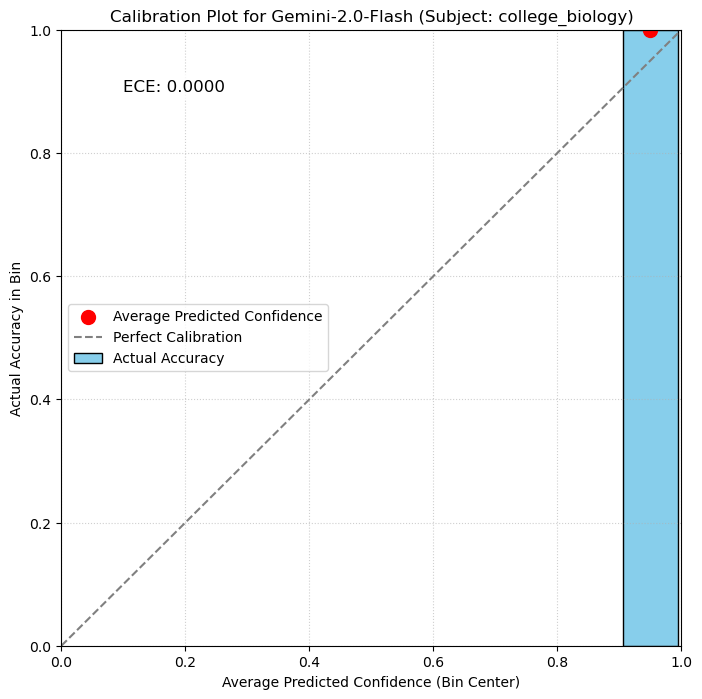

In [6]:

# Create calibration plot, using the Expected Calibration Error (ECE)
NUM_BINS = 10 
bin_edges = np.linspace(0.0, 1.0, NUM_BINS + 1) 

# ensure there is something in results_df
if len(results_df) == 0:
    print("error: results_df is empty.")
    exit()

# bin the confidence scores, using pd.cut (assigns data values to bins)
results_df['bin'] = pd.cut(
    results_df['chosen_probability'], 
    bins=bin_edges, 
    labels=False, 
    include_lowest=True # whether the first interval should be left-inclusive or not
)

# calculating metrics per bin
calibration_data = results_df.groupby('bin').agg(
    # calculate average predicted probability per bin
    avg_confidence=('chosen_probability', 'mean'),
    # calculate the actual accuracy, using the 'is_correct' boolean in the bin
    avg_accuracy=('is_correct', 'mean'),
    # count the samples in the bin
    count=('id', 'count') 
).reset_index() # reset_index moves the current index (the values of the 'bin' column) out of the index position and converts it back into a standard df column named 'bin'

# replace nan values with 0s
calibration_data = calibration_data.fillna(0)

# calculate the center of each bin
def calculate_bin_center(bin_index):
    bin_index = int(bin_index) 
    return (bin_edges[bin_index] + bin_edges[bin_index + 1]) / 2.0

# get correct center for each row
calibration_data['bin_center'] = calibration_data['bin'].apply(calculate_bin_center)


# Calculate ECE!
# first the weights of each bin: (number of samples in bin) / (total number of samples)
calibration_data['weight'] = calibration_data['count'] / calibration_data['count'].sum()

# ECE
calibration_data['ece_term'] = calibration_data['weight'] * np.abs(
    calibration_data['avg_accuracy'] - calibration_data['avg_confidence']
)
ece = calibration_data['ece_term'].sum()

print(f"\nExpected Calibration Error (ECE): {ece:.6f}")
print("-" * 50)


# PLOT
fig, ax = plt.subplots(figsize=(8, 8))

# plot calibration curve (accuracy vs confidence)
ax.bar(
    calibration_data['bin_center'], 
    calibration_data['avg_accuracy'], 
    width=(1/NUM_BINS) * 0.9, # Bar width slightly less than bin width
    color='skyblue', 
    edgecolor='black',
    label='Actual Accuracy'
)

# plot difference between acc and conf
ax.scatter(
    calibration_data['bin_center'],
    calibration_data['avg_confidence'],
    marker='o',
    color='red',
    s=100,
    label='Average Predicted Confidence'
)

# plot desired perfect calibration line
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')

# Set labels and title
ax.set_xlabel('Average Predicted Confidence (Bin Center)')
ax.set_ylabel('Actual Accuracy in Bin')
ax.set_title(f'Calibration Plot for Gemini-2.0-Flash (Subject: {dataset_name})')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)

# Add ECE text to the plot
ax.text(0.1, 0.9, f'ECE: {ece:.4f}', transform=ax.transAxes, fontsize=12, 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Display the plot
plt.show()

## Defining calibration plot function


In [9]:


# Constants outside the function
ANSWER_MAP = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}
MODEL_NAME = "gemini-2.0-flash" 
MAX_OUTPUT_TOKENS = 5 
BASE_URL = "hf://datasets/cais/mmlu/"


def calibration_plot(dataset_name: str, number_of_bins: int):
    """
    Generates a calibration plot for the specified MMLU dataset using the Gemini API.

    Args:
        dataset_name (str): The name of the MMLU dataset subset (e.g., 'college_biology').
        number_of_bins (int): The number of bins to use for the calibration plot.
    """
    
    # DATA LOADING
    
    splits = {
        'test': f'{dataset_name}/test-00000-of-00001.parquet',
        'validation': f'{dataset_name}/validation-00000-of-00001.parquet',
        'dev': f'{dataset_name}/dev-00000-of-00001.parquet'
    }
    
    try:
        # Load the FULL dataset for proper calibration (removed .head(5))
        df = pd.read_parquet(BASE_URL + splits["test"])
    except Exception as e:
        print(f"Error loading dataset '{dataset_name}': {e}")
        return

    
    # API SET UP
    
    try:
        # Client needs to be accessible, assuming it's initialized globally or passed in.
        # Since your original code initializes it, we'll assume 'client' is defined here.
        client = genai.Client()
        print("Gemini API Client initialized.")
    except Exception as e:
        print(f"Error when initializing client: {e}")
        if not os.environ.get("GEMINI_API_KEY"):
            print("ERROR: GEMINI_API_KEY not found in environment.")
        return # Use return instead of exit() inside a function

    
    # API CALLS
    
    results = [] # to store results of api calls

    print(f"\nStarting API calls for {len(df)} questions in '{dataset_name}'...")

    # iterate through dataframe
    for index, row in df.iterrows(): 
        # map the integer answer to the actual letter using the  ANSWER_MAP dict
        correct_answer_index = row['answer'] 
        correct_answer_letter = ANSWER_MAP.get(correct_answer_index, 'UNKNOWN')
        
        # skip if answer is unknown
        if correct_answer_letter == 'UNKNOWN':
            continue

        question_text = row['question'] # the actual question in the dataset
        choices = row['choices'] # the multiple choice options for the answer
        
        # make a nice format of the options so that the prompt is correct and easy to read
        option_lines = [f"{letter}. {text}" for letter, text in zip(['A', 'B', 'C', 'D'], choices)]
        
        # construct the final structured prompt
        full_prompt = (
            f"{question_text}\n" + 
            "\n".join(option_lines) +
            "\n\nPlease only answer with a single letter (A, B, C, or D) and nothing else."
        )
        
        # make API call and store log probabilities!
        try:
            response = client.models.generate_content(
                model=MODEL_NAME,  
                contents=full_prompt, 
                config=GenerateContentConfig(
                    max_output_tokens=MAX_OUTPUT_TOKENS,
                    response_logprobs=True,
                    logprobs=5,
                )
            )
            
            # Process the response of the model
            final_answer = response.text.strip().upper() # make sure it's upper case
            logprob_content = response.candidates[0].logprobs_result # store the log probabilities
            
            chosen_candidates_list = logprob_content.chosen_candidates
            
            if chosen_candidates_list:
                first_token_info = chosen_candidates_list[0] 
                chosen_logprob = first_token_info.log_probability 

                chosen_probability = math.exp(chosen_logprob)
                safe_probability = min(chosen_probability, 1.0) # clip probability to max 1.0 to avoid floating point errors
                
                results.append({
                    'id': index,
                    'correct_answer': correct_answer_letter,
                    'model_answer': final_answer,
                    'is_correct': final_answer == correct_answer_letter,
                    'chosen_logprob': chosen_logprob,
                    'chosen_probability': safe_probability
                })
                
            else:
                print(f"Q {index+1}: WARNING: Model generated no tokens.")

        except Exception as e:
            # catch errors to prevent one single error of stopping entire function
            print(f"Error during API call for Q {index+1}: {e}. Skipping...")
            continue
            
    print("\nAPI calls complete.")

    
    # CALIBRATION
    
    results_df = pd.DataFrame(results)
    
    if len(results_df) == 0:
        print("error: results_df is empty after API calls.")
        return

    # quick analysation of results
    print("\n--- Results Summary ---")
    print(f"Total questions processed: {len(results_df)}")
    print(f"Overall Accuracy: {results_df['is_correct'].mean():.6f}")
    
    # Create calibration plot, using the Expected Calibration Error (ECE)
    bin_edges = np.linspace(0.0, 1.0, number_of_bins + 1) 

    # bin the confidence scores, using pd.cut
    results_df['bin'] = pd.cut(
        results_df['chosen_probability'], 
        bins=bin_edges, 
        labels=False, 
        include_lowest=True
    )

    # calculating metrics per bin
    calibration_data = results_df.groupby('bin').agg(
        avg_confidence=('chosen_probability', 'mean'),
        avg_accuracy=('is_correct', 'mean'),
        count=('id', 'count') 
    ).reset_index()

    # replace nan values with 0s
    calibration_data = calibration_data.fillna(0)

    # calculate the center of each bin
    def calculate_bin_center(bin_index):
        bin_index = int(bin_index) 
        return (bin_edges[bin_index] + bin_edges[bin_index + 1]) / 2.0

    # get correct center for each row
    calibration_data['bin_center'] = calibration_data['bin'].apply(calculate_bin_center)


    # Calculate ECE!
    # first the weights of each bin
    calibration_data['weight'] = calibration_data['count'] / calibration_data['count'].sum()

    # ECE
    calibration_data['ece_term'] = calibration_data['weight'] * np.abs(
        calibration_data['avg_accuracy'] - calibration_data['avg_confidence']
    )
    ece = calibration_data['ece_term'].sum()

    print(f"\nExpected Calibration Error (ECE): {ece:.6f}")
    print("-" * 50)


    # PLOTTING
    
    fig, ax = plt.subplots(figsize=(8, 8))

    # plotting actual accuracy 
    ax.bar(
        calibration_data['bin_center'], 
        calibration_data['avg_accuracy'], 
        width=(1/number_of_bins) * 0.9, # Bar width slightly less than bin width
        color='skyblue', 
        edgecolor='black',
        label='Actual Accuracy'
    )

    # Print number of samples in each bin
    for _, row in calibration_data.iterrows():
        count = row['count']
        center = row['bin_center']
        
        if count >= 0:
            # Set y-coordinate to a small fixed value (e.g., 0.02) just above the axis.
            # Use 'va="bottom"' to ensure the text starts at 0.02 and doesn't overlap the axis.
            ax.text(
                center, 
                0.02, # Fixed y-coordinate close to the bottom (X-axis)
                f'N={int(count)}',
                ha='center',       # Horizontal alignment (centered on the bar)
                va='bottom',       # Vertical alignment (text base starts at y=0.02)
                fontsize=9,        
                color='black',
                weight='bold'      # Added bolding for better visibility against the blue bar
            )
            

    # plot difference between acc and conf
    ax.scatter(
        calibration_data['bin_center'],
        calibration_data['avg_confidence'],
        marker='o',
        color='red',
        s=100,
        label='Average Predicted Confidence'
    )

    # plot desired perfect calibration line
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')

    # Set labels and title
    ax.set_xlabel('Average Predicted Confidence (Bin Center)')
    ax.set_ylabel('Actual Accuracy in Bin')
    ax.set_title(f'Calibration Plot for {MODEL_NAME} (Subject: {dataset_name}. Ntot={len(df)}.)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

    # Add ECE text to the plot
    ax.text(0.1, 0.9, f'ECE: {ece:.4f}', transform=ax.transAxes, fontsize=12, 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    # display the plot
    plt.show()




Gemini API Client initialized.

Starting API calls for 144 questions in 'college_biology'...

API calls complete.

--- Results Summary ---
Total questions processed: 144
Overall Accuracy: 0.965278

Expected Calibration Error (ECE): 0.033795
--------------------------------------------------


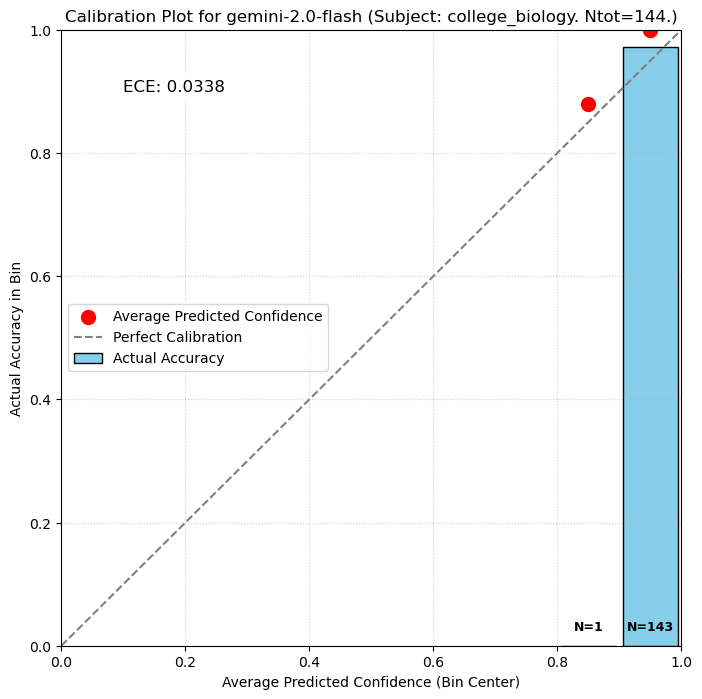

Gemini API Client initialized.

Starting API calls for 173 questions in 'college_medicine'...

API calls complete.

--- Results Summary ---
Total questions processed: 173
Overall Accuracy: 0.849711

Expected Calibration Error (ECE): 0.135698
--------------------------------------------------


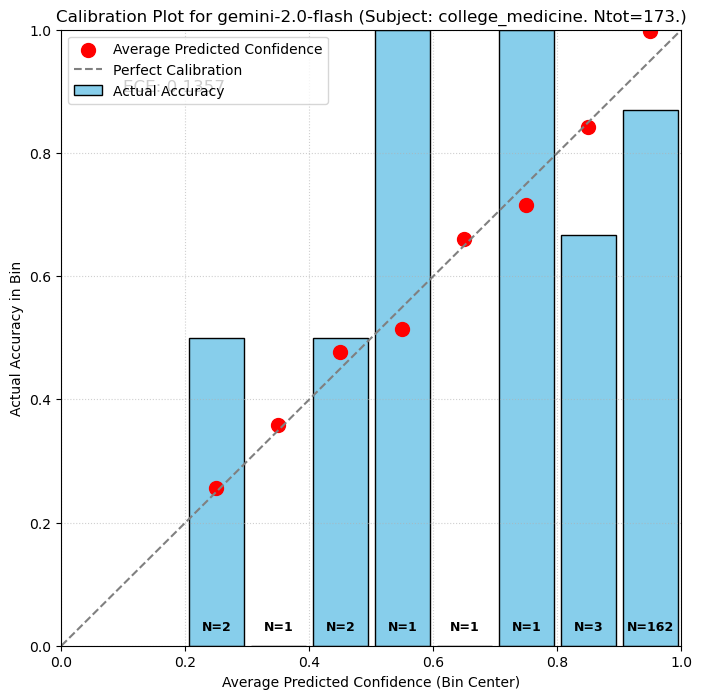

Gemini API Client initialized.

Starting API calls for 235 questions in 'conceptual_physics'...

API calls complete.

--- Results Summary ---
Total questions processed: 235
Overall Accuracy: 0.902128

Expected Calibration Error (ECE): 0.083960
--------------------------------------------------


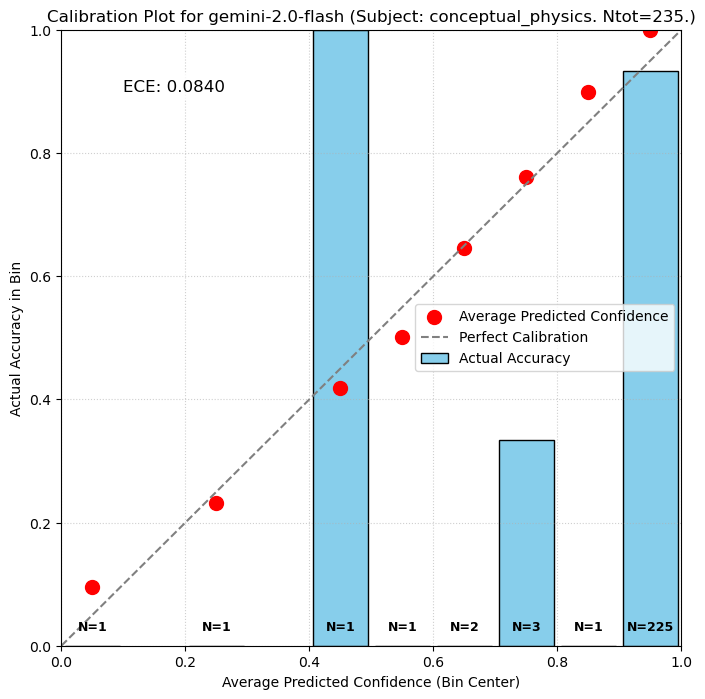

Error loading dataset 'econometrics': (MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /api/datasets/cais/mmlu/paths-info/main (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000001BAC3DCF5D0>: Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 0e1a7f56-218f-4c1c-bda6-c59d84eec180)')
Gemini API Client initialized.

Starting API calls for 310 questions in 'high_school_biology'...

API calls complete.

--- Results Summary ---
Total questions processed: 310
Overall Accuracy: 0.938710

Expected Calibration Error (ECE): 0.054995
--------------------------------------------------


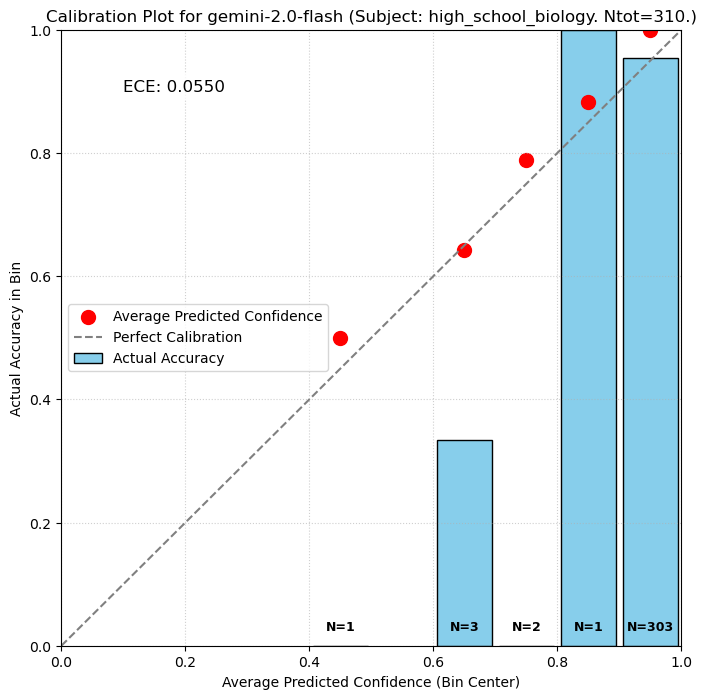

'(ReadTimeoutError("HTTPSConnectionPool(host='cas-bridge.xethub.hf.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 74430113-4bd9-4d27-9f85-128a1fe12542)')' thrown while requesting GET https://huggingface.co/datasets/cais/mmlu/resolve/main/high_school_psychology/test-00000-of-00001.parquet
Retrying in 1s [Retry 1/5].


Gemini API Client initialized.

Starting API calls for 545 questions in 'high_school_psychology'...

API calls complete.

--- Results Summary ---
Total questions processed: 545
Overall Accuracy: 0.946789

Expected Calibration Error (ECE): 0.051830
--------------------------------------------------


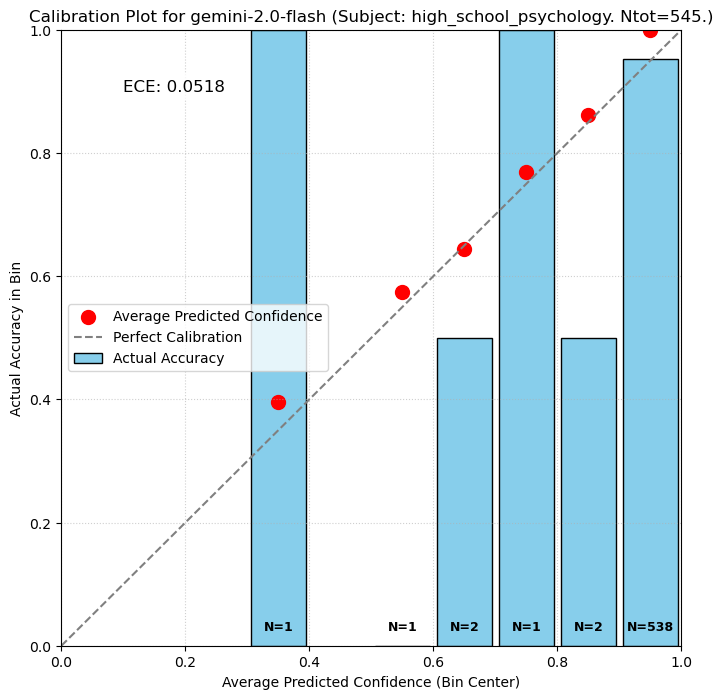

Gemini API Client initialized.

Starting API calls for 272 questions in 'professional_medicine'...
Error during API call for Q 1: Server disconnected without sending a response.. Skipping...

API calls complete.

--- Results Summary ---
Total questions processed: 271
Overall Accuracy: 0.940959

Expected Calibration Error (ECE): 0.057895
--------------------------------------------------


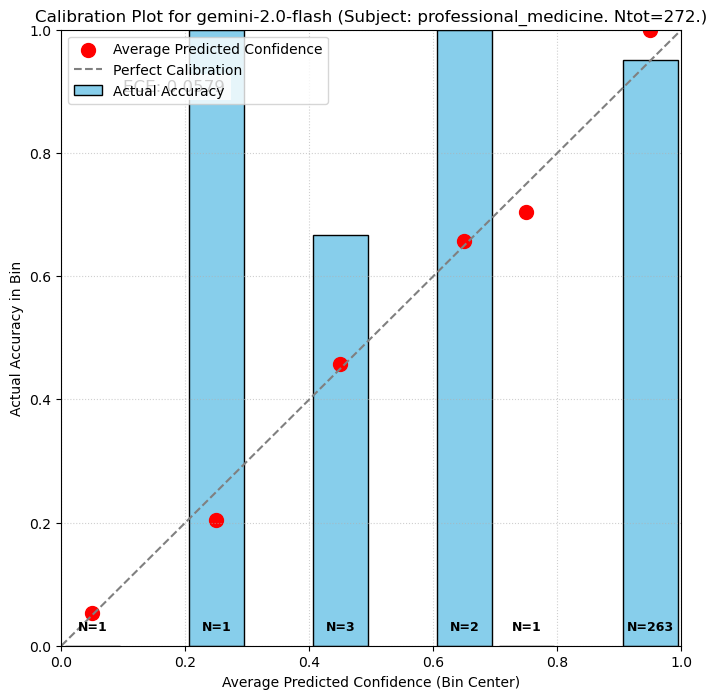

Gemini API Client initialized.

Starting API calls for 612 questions in 'professional_psychology'...

API calls complete.

--- Results Summary ---
Total questions processed: 612
Overall Accuracy: 0.885621

Expected Calibration Error (ECE): 0.107860
--------------------------------------------------


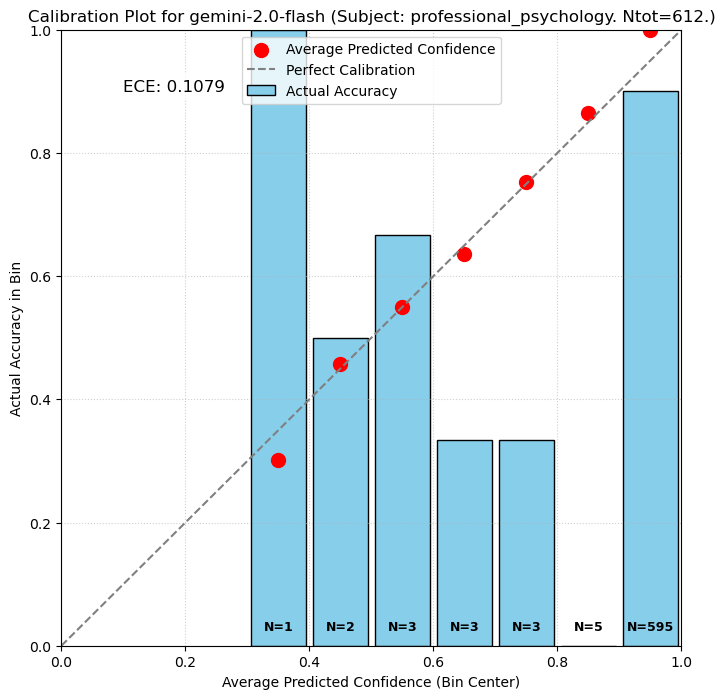

In [11]:
number_of_bins = 10
data_sets = ['college_biology', 'college_medicine', 'conceptual_physics', 'econometrics', 'high_school_biology', 'high_school_psychology',
             'professional_medicine', 'professional_psychology']
for data_set in data_sets:
    calibration_plot(data_set, number_of_bins)